In [1]:
from math import exp, factorial
V = [[0.0 for j in range(21)] for i in range(21)]
policy = [[0 for j in range(21)] for i in range(21)]

theta=1e-4
gamma=0.9
onerequest=3 #location one lambda request
tworequest=4 #location two lambda request
onereturn=3 #location one lambda return
tworeturn=2 #location two lambda return



In [2]:
poisson_cache={}
def poisson(lam, n):
    if (lam, n) not in poisson_cache:
        poisson_cache[(lam, n)] = exp(-lam) * lam**n / factorial(n)
    return poisson_cache[(lam, n)]
MAX_POISSON = 10

def poisson_probs(lam):
    probs = [poisson(lam, n) for n in range(MAX_POISSON)]
    probs.append(1 - sum(probs))  # tail mass
    return probs
poisson_table = {
    onerequest: poisson_probs(onerequest),
    tworequest: poisson_probs(tworequest),
    onereturn: poisson_probs(onereturn),
    tworeturn: poisson_probs(tworeturn),
}

In [5]:
def expected_return(i,j,a,V):
    idash=min(max(i-a,0),20)
    jdash=min(max(j+a,0),20)
    cost=2*abs(a)
    total=0.0
    for p in range(11):
        for q in range(11):
            poison=poisson_table[onerequest][p]*poisson_table[tworequest][q]
            idashh=idash-min(idash,p)
            jdashh=jdash-min(jdash,q)
            reward=(10*(min(idash,p)+min(jdash,q)))-cost
            for p1 in range(11):
                for q1 in range(11):
                    poisonous=poison*poisson_table[onereturn][p1]*poisson_table[tworeturn][q1]
                    idashhh=min(20,idashh+p1)
                    jdashhh=min(20,jdashh+q1)
                    total+=(poisonous*(reward+gamma*(V[idashhh][jdashhh])))        
    return total

while True:
    delta = 0
    statevalue=[[0.0 for j in range(21)] for i in range(21)]
    for i in range(21):
        for j in range(21):
            v_old = V[i][j]
            a = policy[i][j]
            statevalue[i][j] = expected_return(i, j, a, V)
            delta = max(delta, abs(v_old - statevalue[i][j]))
    V=statevalue
    if delta < theta:
        break

print(V)

[[407.16990350613213, 417.1439738311842, 427.0092753876909, 436.64081192778485, 445.92421861571006, 454.79494787717186, 463.2390274185664, 471.27128901380274, 478.91486508077537, 486.19140268002513, 493.11929820362536, 499.71070554598174, 505.98643594538845, 511.9585999517042, 517.638260601882, 523.032939721994, 528.1427005657113, 532.9532431668121, 537.4252772375766, 541.4838689439221, 545.0199055624635], [416.9897304834282, 426.96380080847376, 436.82910236498583, 446.46063890507963, 455.74404559300035, 464.6147748544681, 473.05885439586444, 481.09111599109616, 488.7346920580687, 496.0112296573178, 502.9391251809221, 509.530532523273, 515.8062629226772, 521.7784269290003, 527.458087579179, 532.8527666992914, 537.9625275430077, 542.7730701441066, 547.245104214874, 551.3036959212199, 554.8397325397577], [426.22381404513396, 436.19788437018696, 446.0631859266997, 455.69472246678635, 464.97812915470996, 473.8488584161806, 482.2929379575707, 490.325199552808, 497.9687756197765, 505.2453132

In [7]:
def expected_return(i,j,a,V):
    idash=min(max(i-a,0),20)
    jdash=min(max(j+a,0),20)
    cost=2*abs(a)
    total=0.0
    for p in range(11):
        for q in range(11):
            poison=poisson_table[onerequest][p]*poisson_table[tworequest][q]
            idashh=idash-min(idash,p)
            jdashh=jdash-min(jdash,q)
            reward=(10*(min(idash,p)+min(jdash,q)))-cost
            for p1 in range(11):
                for q1 in range(11):
                    poisonous=poison*poisson_table[onereturn][p1]*poisson_table[tworeturn][q1]
                    idashhh=min(20,idashh+p1)
                    jdashhh=min(20,jdashh+q1)
                    total+=(poisonous*(reward+gamma*(V[idashhh][jdashhh])))        
    return total

while True:
    while True:
        delta = 0
        statevalue=[[0.0 for j in range(21)] for i in range(21)]
        for i in range(21):
            for j in range(21):
                v_old = V[i][j]
                a = policy[i][j]
                statevalue[i][j] = expected_return(i, j, a, V)
                delta = max(delta, abs(v_old - statevalue[i][j]))
        V=statevalue
        if delta < theta:
            break
        
    policy_stable=True
    for i in range(21):
        for j in range(21):
            olda=policy[i][j]
            bestval=float('-inf')
            bestaction=olda
            for a in range(-5,6):
                if(a<=i) and (-a<=j):
                    val= expected_return(i,j,a,V)
                    if val>bestval:
                        bestval=val
                        bestaction=a
            policy[i][j]=bestaction
            if bestaction!=olda:
                policy_stable=False
    if policy_stable==True:
        break
        
print(V)

[[421.3944668364299, 431.36668994707844, 441.222390525661, 450.8277415023552, 460.0606096712965, 468.85281542002645, 477.1912693607944, 485.095107930421, 492.95841093179195, 500.4542156358598, 507.8663203626569, 514.9718152548228, 521.7285950054048, 528.3288999836979, 534.7174762558966, 540.8040176417022, 546.6067894243057, 552.1421225661331, 557.5662702240944, 562.7689271756398, 567.7182433827828], [431.2682229856684, 441.2403798909845, 451.0957519486134, 460.7002603547542, 469.93162473711993, 478.7216987716379, 487.0575386740186, 494.9584109317956, 502.4542156358626, 509.8663203626535, 516.9718152548216, 523.7285950054076, 530.3288999836982, 536.7174762559034, 542.8040176417047, 548.6067894243157, 554.1421225661329, 559.5662702241044, 564.7689271756442, 569.7182433827857, 574.4054598663478], [440.7417963692328, 450.71364678967234, 460.5674999214289, 470.1681205979517, 479.39257137363995, 488.17290941672854, 496.4969493840152, 504.3846847307304, 511.8663203626575, 518.9718152548259, 5

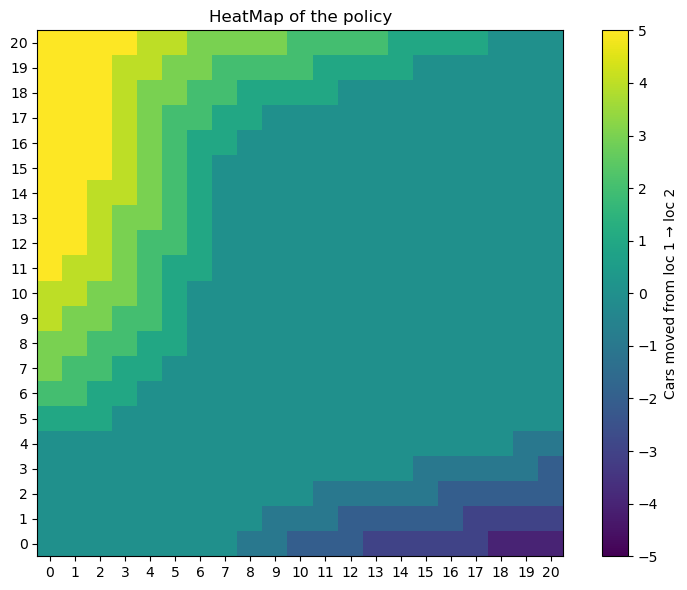

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

policy_arr = np.array(policy)

plt.figure(figsize=(8, 6))

im = plt.imshow(
    policy_arr,
    origin='lower',
    cmap='viridis',
    vmin=-5,
    vmax=5
)
plt.xticks(ticks=np.arange(21), labels=np.arange(21))
plt.yticks(ticks=np.arange(21), labels=np.arange(21))

cbar = plt.colorbar(im)
cbar.set_ticks(np.arange(-5, 6, 1))
cbar.set_label('Cars moved from loc 1 → loc 2')

plt.title('HeatMap of the policy')

plt.tight_layout()
plt.show()